# CW-ODMR spectrum scan -- new amplifier (`amp1`, `amp2`, `amp2_again`, `amp3`, `amp4`)

Same as `cw_odmr_spectrum.ipynb`'s `run_spectrum` plots, but for the new-amplifier
runs (`amp1/`, `amp2/`, `amp2_again/`, `amp3/`, `amp4/`), kept in a separate notebook/plot from the earlier
`trial1`-`trial6` data taken with the old amplifier. No live instrument connection
needed here -- everything comes from the saved `.npy`/metadata files.

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/cw_odmr"
TRIAL_NAMES = ["amp1", "amp2", "amp2_again", "amp3", "amp4"]

## Load all trials

In [2]:
def load_trial(name):
    run_path = f"{DATA_DIR}/{name}"
    spectrum = np.load(f"{run_path}/{name}_spectrum.npy")
    freqs_hz = np.load(f"{run_path}/{name}_spectrum_freqs_hz.npy")

    seg_means = spectrum.mean(axis=2)  # (freq_points, segments_per_point)
    avg_voltage = seg_means.mean(axis=1)
    sem_voltage = seg_means.std(axis=1) / np.sqrt(seg_means.shape[1])

    trial = {
        "name": name,
        "freqs_ghz": freqs_hz / 1e9,
        "avg_voltage": avg_voltage,
        "sem_voltage": sem_voltage,
        "step_khz": (freqs_hz[1] - freqs_hz[0]) / 1e3,
        "segments_per_point": spectrum.shape[1],
    }

    bg_path = f"{run_path}/{name}_bg.npy"
    if os.path.exists(bg_path):
        bg_seg_mean = np.load(bg_path).mean(axis=-1)
        bg_mean = bg_seg_mean.mean()
        bg_sem = bg_seg_mean.std() / np.sqrt(len(bg_seg_mean))
        trial["bg_mean"] = bg_mean
        trial["bg_sem"] = bg_sem
        trial["net_voltage"] = avg_voltage - bg_mean
        trial["net_err"] = np.sqrt(sem_voltage**2 + bg_sem**2)

    return trial


trials = [load_trial(name) for name in TRIAL_NAMES]

for t in trials:
    has_bg = "bg_mean" in t
    print(f"{t['name']}: {t['freqs_ghz'].min():.6f}-{t['freqs_ghz'].max():.6f} GHz "
          f"({t['step_khz']:.1f} kHz step, {t['segments_per_point']} segments/point), "
          f"voltage {t['avg_voltage'].min():.5f} to {t['avg_voltage'].max():.5f} V"
          + (f", background = {t['bg_mean']:.5f} +/- {t['bg_sem']:.6f} V" if has_bg else
             ", no background acquisition"))

amp1: 2.890525-2.902025 GHz (100.0 kHz step, 20 segments/point), voltage -0.01299 to -0.00890 V, background = -0.01159 +/- 0.000074 V
amp2: 2.863750-2.876450 GHz (100.0 kHz step, 20 segments/point), voltage -0.01226 to -0.00699 V, no background acquisition
amp2_again: 2.877925-2.889165 GHz (40.0 kHz step, 100 segments/point), voltage -0.01363 to -0.00797 V, background = -0.01055 +/- 0.000069 V
amp3: 2.866775-2.878415 GHz (40.0 kHz step, 100 segments/point), voltage -0.01421 to -0.00711 V, background = -0.00948 +/- 0.000069 V
amp4: 2.861075-2.874675 GHz (100.0 kHz step, 20 segments/point), voltage -0.01414 to -0.00909 V, no background acquisition


## Average signal voltage vs. frequency

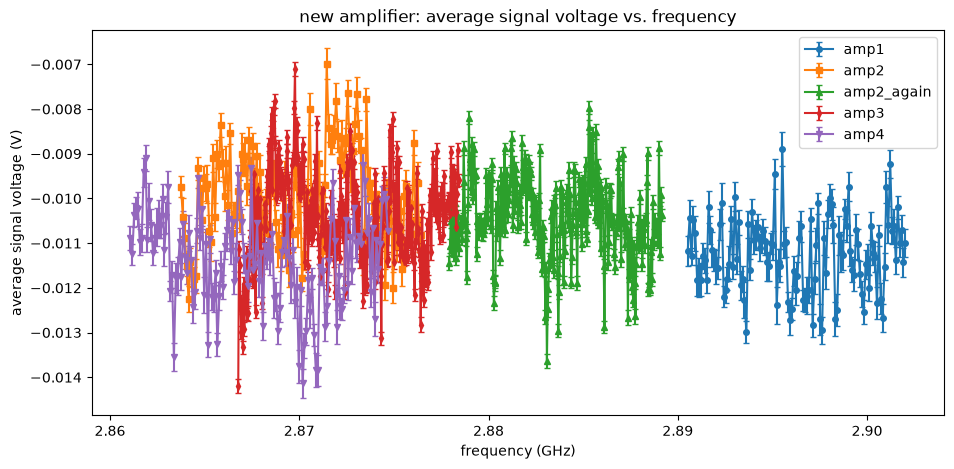

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

markers = ["o", "s", "^", "d", "v", "P", "X", "*"]
for i, t in enumerate(trials):
    ax.errorbar(t["freqs_ghz"], t["avg_voltage"], yerr=t["sem_voltage"],
                fmt=markers[i % len(markers)] + "-", ms=4, capsize=2,
                color=f"C{i}", label=t["name"])

ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("average signal voltage (V)")
ax.set_title("new amplifier: average signal voltage vs. frequency")
ax.legend()
plt.show()

## Background-subtracted spectra

Trials with a saved RF-off `_bg.npy` acquisition have their own background segment
mean subtracted off. Trials without one (e.g. `amp2`, if no `run_background` has been
taken for it yet) are excluded here.

amp2: no background acquisition -- skipping
amp4: no background acquisition -- skipping


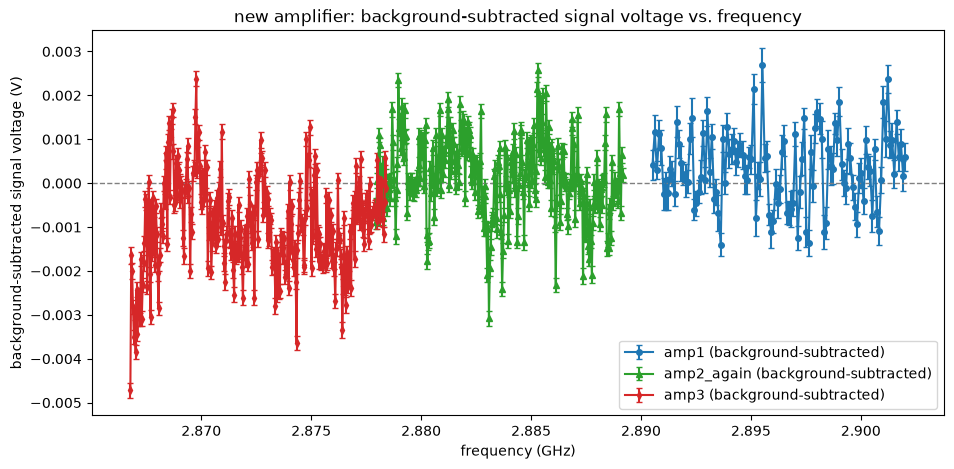

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, t in enumerate(trials):
    if "net_voltage" not in t:
        print(f"{t['name']}: no background acquisition -- skipping")
        continue
    ax.errorbar(t["freqs_ghz"], t["net_voltage"], yerr=t["net_err"],
                fmt=markers[i % len(markers)] + "-", ms=4, capsize=2,
                color=f"C{i}", label=f"{t['name']} (background-subtracted)")

ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("background-subtracted signal voltage (V)")
ax.set_title("new amplifier: background-subtracted signal voltage vs. frequency")
ax.legend()
plt.show()

## Reflected power vs. frequency (sanity check)

The per-point reflected-power reading used for the inline interlock check during each
scan (solid lines) -- should trace out the resonance's reflection dip shape across the
scanned span, as a sanity check that each scan actually covered the resonance. Each
trial's own `resonance_fine.csv` sweep (dashed lines, same color) is overlaid for
comparison -- that's the higher-resolution dedicated resonance sweep taken just before
the `run_spectrum` scan, so the two should agree on where the dip sits.

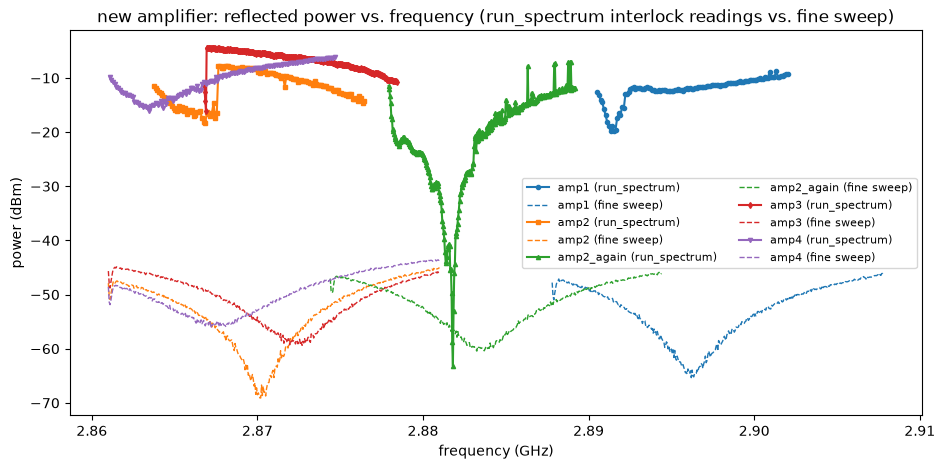

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, name in enumerate(TRIAL_NAMES):
    reflected_dbm = np.load(f"{DATA_DIR}/{name}/{name}_spectrum_reflected_dbm.npy")
    freqs_ghz = trials[i]["freqs_ghz"]
    ax.plot(freqs_ghz, reflected_dbm, markers[i % len(markers)] + "-", ms=3,
            color=f"C{i}", label=f"{name} (run_spectrum)")

    fine = np.genfromtxt(f"{DATA_DIR}/{name}/{name}_resonance_fine.csv",
                          delimiter=",", names=True)
    ax.plot(fine["frequency_hz"] / 1e9, fine["power_dbm"], "--", lw=1,
            color=f"C{i}", label=f"{name} (fine sweep)")

ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title("new amplifier: reflected power vs. frequency "
             "(run_spectrum interlock readings vs. fine sweep)")
ax.legend(fontsize=8, ncol=2)
plt.show()

## Correlation: reflected power vs. signal voltage

Checks whether the per-frequency-point reflected power and average signal voltage
track each other -- e.g. if the resonance dip in reflected power (more power
absorbed/coupled into the resonator) coincides with a change in signal voltage, that
would show up as a nonzero correlation. Pearson's r is computed per trial (each
trial's own frequency points) and pooled across all trials together.

amp1: Pearson r = +0.020 (p = 8.35e-01, N = 116)
amp2: Pearson r = -0.030 (p = 7.35e-01, N = 128)
amp2_again: Pearson r = -0.255 (p = 1.44e-05, N = 282)
amp3: Pearson r = +0.084 (p = 1.53e-01, N = 292)
amp4: Pearson r = -0.107 (p = 2.14e-01, N = 137)


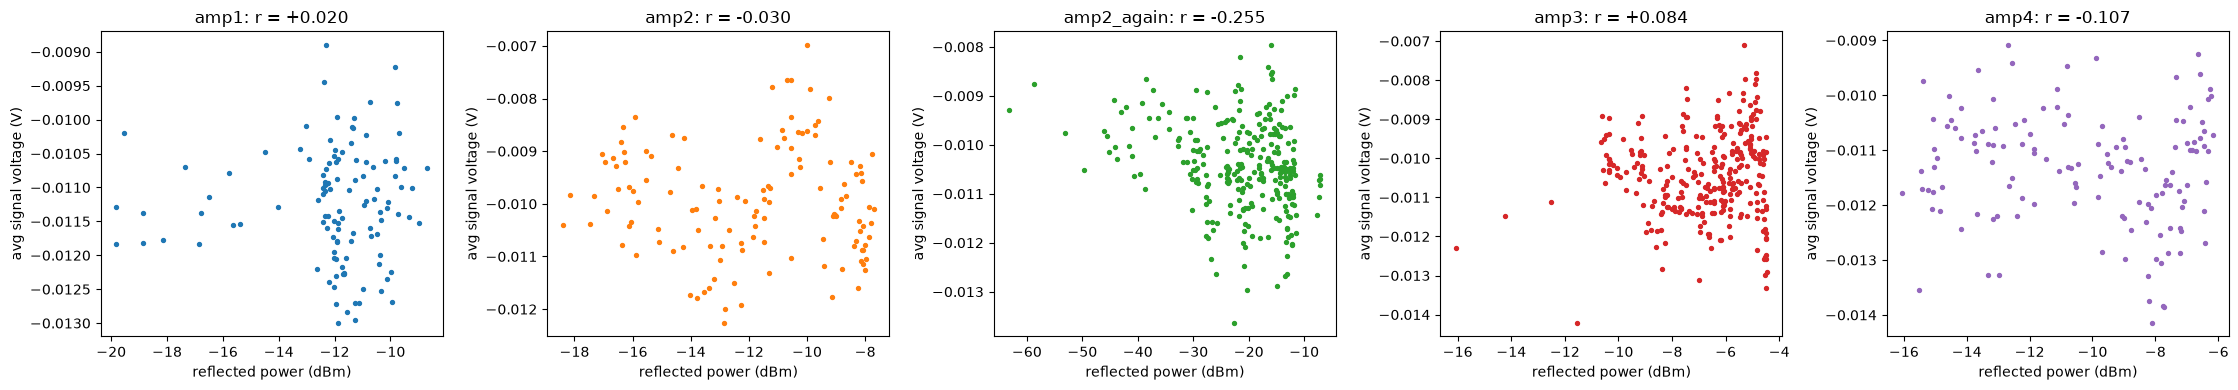

pooled across all 5 trials (N=955): Pearson r = -0.117 (p = 2.85e-04)
(pooling trials with different f0/frequency ranges together conflates within-trial trends with any overall offset between trials -- treat the per-trial r values above as the more meaningful ones)


In [6]:
from scipy.stats import pearsonr

all_reflected_dbm = []
all_avg_voltage = []

fig, axes = plt.subplots(1, len(TRIAL_NAMES), figsize=(4.5 * len(TRIAL_NAMES), 4),
                          sharey=False)
for i, (name, ax) in enumerate(zip(TRIAL_NAMES, axes)):
    reflected_dbm = np.load(f"{DATA_DIR}/{name}/{name}_spectrum_reflected_dbm.npy")
    avg_voltage = trials[i]["avg_voltage"]

    r, p = pearsonr(reflected_dbm, avg_voltage)
    print(f"{name}: Pearson r = {r:+.3f} (p = {p:.2e}, N = {len(reflected_dbm)})")

    ax.scatter(reflected_dbm, avg_voltage, s=8, color=f"C{i}")
    ax.set_xlabel("reflected power (dBm)")
    ax.set_ylabel("avg signal voltage (V)")
    ax.set_title(f"{name}: r = {r:+.3f}")

    all_reflected_dbm.append(reflected_dbm)
    all_avg_voltage.append(avg_voltage)

plt.tight_layout()
plt.show()

all_reflected_dbm = np.concatenate(all_reflected_dbm)
all_avg_voltage = np.concatenate(all_avg_voltage)
r_pooled, p_pooled = pearsonr(all_reflected_dbm, all_avg_voltage)
print(f"pooled across all {len(TRIAL_NAMES)} trials (N={len(all_reflected_dbm)}): "
      f"Pearson r = {r_pooled:+.3f} (p = {p_pooled:.2e})")
print("(pooling trials with different f0/frequency ranges together conflates "
      "within-trial trends with any overall offset between trials -- treat the "
      "per-trial r values above as the more meaningful ones)")

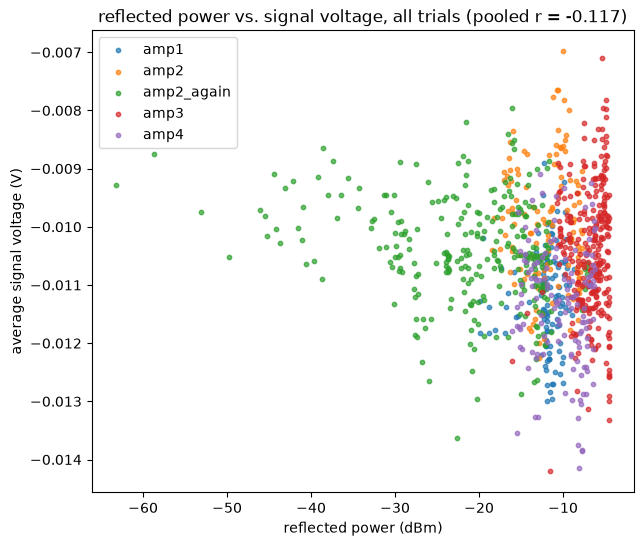

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for i, name in enumerate(TRIAL_NAMES):
    reflected_dbm = np.load(f"{DATA_DIR}/{name}/{name}_spectrum_reflected_dbm.npy")
    avg_voltage = trials[i]["avg_voltage"]
    ax.scatter(reflected_dbm, avg_voltage, s=10, color=f"C{i}", label=name, alpha=0.7)

ax.set_xlabel("reflected power (dBm)")
ax.set_ylabel("average signal voltage (V)")
ax.set_title(f"reflected power vs. signal voltage, all trials "
             f"(pooled r = {r_pooled:+.3f})")
ax.legend()
plt.show()

## Time-drift confound check

`amp2_again` showed a significant reflected-power/voltage correlation above, but `amp3` (same 100 segments/point, similar N) didn't -- despite having an even *stronger* reflected-power-vs-scan-order trend. That's the signature of a confound, not a real reflected-power effect: since frequency points are swept roughly in scan order (point index acts as a rough proxy for elapsed time), a trial where the signal voltage ALSO drifts slowly over time will show a spurious correlation with reflected power whenever reflected power happens to trend across the scan too -- two unrelated quantities that both happen to correlate with time, not with each other. If reflected power itself were the real driver, the trial with the STRONGER reflected-power-vs-time trend (amp3) should show the bigger effect, not the smaller one.

In [8]:
for i, name in enumerate(TRIAL_NAMES):
    reflected_dbm = np.load(f"{DATA_DIR}/{name}/{name}_spectrum_reflected_dbm.npy")
    avg_voltage = trials[i]["avg_voltage"]
    point_index = np.arange(len(avg_voltage))

    r_v_refl, p_v_refl = pearsonr(reflected_dbm, avg_voltage)
    r_v_idx, p_v_idx = pearsonr(point_index, avg_voltage)
    r_refl_idx, p_refl_idx = pearsonr(point_index, reflected_dbm)

    print(f"{name}:")
    print(f"  voltage vs reflected power:  r={r_v_refl:+.3f}  p={p_v_refl:.2e}")
    print(f"  voltage vs point index/time: r={r_v_idx:+.3f}  p={p_v_idx:.2e}")
    print(f"  reflected power vs index:    r={r_refl_idx:+.3f}  p={p_refl_idx:.2e}")
    print()

print("amp3 has a MUCH stronger reflected-power-vs-time trend than amp2_again but "
      "shows no voltage correlation at all -- amp2_again's apparent reflected-power "
      "correlation is better explained by its own independent slow voltage drift "
      "over the scan coinciding with reflected power's trend, not a real causal "
      "link between reflected power and signal voltage.")

amp1:
  voltage vs reflected power:  r=+0.020  p=8.35e-01
  voltage vs point index/time: r=+0.024  p=8.02e-01
  reflected power vs index:    r=+0.793  p=2.56e-26

amp2:
  voltage vs reflected power:  r=-0.030  p=7.35e-01
  voltage vs point index/time: r=+0.085  p=3.37e-01
  reflected power vs index:    r=+0.271  p=2.00e-03

amp2_again:
  voltage vs reflected power:  r=-0.255  p=1.44e-05
  voltage vs point index/time: r=-0.163  p=6.00e-03
  reflected power vs index:    r=+0.589  p=9.83e-28

amp3:
  voltage vs reflected power:  r=+0.084  p=1.53e-01
  voltage vs point index/time: r=+0.017  p=7.78e-01
  reflected power vs index:    r=-0.767  p=8.17e-58

amp4:
  voltage vs reflected power:  r=-0.107  p=2.14e-01
  voltage vs point index/time: r=-0.161  p=5.99e-02
  reflected power vs index:    r=+0.905  p=5.19e-52

amp3 has a MUCH stronger reflected-power-vs-time trend than amp2_again but shows no voltage correlation at all -- amp2_again's apparent reflected-power correlation is better expla